<a href="https://colab.research.google.com/github/Niknuby/CSCK507-April-2025-Practical-Assessment-Programming/blob/main/toxic_comment_challenge.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



```
# This is formatted as code
```

# Kaggle Challenge Notebook

This notebook trains machine learning models for a Kaggle competition.

**Requirements**: pandas, numpy, scikit-learn, matplotlib, seaborn.

**How to Run:**
1. Install requirements (first code cell)
2. Upload the required datasets (.csv and.txt files)
3. Run all cells sequentially

In [1]:
# Install required libraries
!pip install pandas numpy scikit-learn matplotlib seaborn

In [2]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Set random seeds for reproducibility
import random
random.seed(42)
np.random.seed(42)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159571 entries, 0 to 159570
Data columns (total 8 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   id             159571 non-null  object
 1   comment_text   159571 non-null  object
 2   toxic          159571 non-null  int64 
 3   severe_toxic   159571 non-null  int64 
 4   obscene        159571 non-null  int64 
 5   threat         159571 non-null  int64 
 6   insult         159571 non-null  int64 
 7   identity_hate  159571 non-null  int64 
dtypes: int64(6), object(2)
memory usage: 9.7+ MB
None
                 id                                       comment_text  toxic  \
0  0000997932d777bf  Explanation\nWhy the edits made under my usern...      0   
1  000103f0d9cfb60f  D'aww! He matches this background colour I'm s...      0   
2  000113f07ec002fd  Hey man, I'm really not trying to edit war. It...      0   
3  0001b41b1c6bb37e  "\nMore\nI can't make any real suggestions on ... 

<ipython-input-4-77564b33a6ca>:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=label_counts.index, y=label_counts.values, palette="viridis")


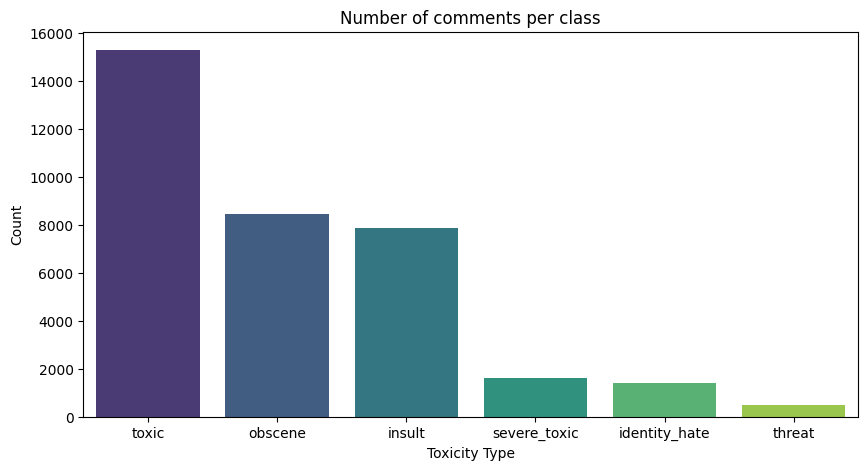

toxic            15294
obscene           8449
insult            7877
severe_toxic      1595
identity_hate     1405
threat             478
dtype: int64
Average number of words per comment: 67.27

Top words in 'toxic' comments:
[('fuck', 9934), ('wikipedia', 3678), ('shit', 3622), ('like', 3512), ('nigger', 3300), ('fucking', 3289), ('suck', 3235), ('ass', 2939), ('u', 2866), ('go', 2865)]

Top words in 'severe_toxic' comments:
[('fuck', 7303), ('suck', 2535), ('ass', 2114), ('shit', 1884), ('u', 1611), ('faggot', 1571), ('fucking', 1456), ('go', 1240), ('die', 1156), ('bitch', 1113)]

Top words in 'obscene' comments:
[('fuck', 9860), ('shit', 3212), ('fucking', 3192), ('suck', 3021), ('ass', 2846), ('nigger', 2727), ('u', 2310), ('go', 2147), ('wikipedia', 1905), ('bitch', 1795)]

Top words in 'threat' comments:
[('die', 1168), ('ass', 772), ('kill', 504), ('going', 294), ('wikipedia', 200), ('block', 170), ('must', 167), ('fuck', 166), ('jim', 158), ('wales', 157)]

Top words in 'insul

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import nltk
from collections import Counter
import re

# Optional: download stopwords
nltk.download('stopwords')
from nltk.corpus import stopwords

# Load data
df = pd.read_csv('train.csv')

# Show basic info
print(df.info())
print(df.head())

# 1. Total number of comments
print(f"Total comments: {len(df)}")

# 2. Check class distributions
label_cols = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']
label_counts = df[label_cols].sum().sort_values(ascending=False)

# Plot distribution
plt.figure(figsize=(10,5))
sns.barplot(x=label_counts.index, y=label_counts.values, palette="viridis")
plt.title("Number of comments per class")
plt.ylabel("Count")
plt.xlabel("Toxicity Type")
plt.show()

# 3. Check for class imbalance
print(label_counts)

# 4. Average sentence length (in tokens)
df['num_words'] = df['comment_text'].apply(lambda x: len(str(x).split()))
avg_length = df['num_words'].mean()
print(f"Average number of words per comment: {avg_length:.2f}")

# 5. Most common words per label (simplified)
stop_words = set(stopwords.words('english'))

def get_top_words(data, label, n=10):
    text = " ".join(data[data[label]==1]['comment_text'])
    text = re.sub(r'\W+', ' ', text.lower())  # clean text
    words = [word for word in text.split() if word not in stop_words]
    common_words = Counter(words).most_common(n)
    return common_words

for label in label_cols:
    print(f"\nTop words in '{label}' comments:")
    print(get_top_words(df, label))


In [5]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.multiclass import OneVsRestClassifier
from sklearn.pipeline import Pipeline

# Prepare data
X = df['comment_text']
y = df[label_cols]

# Split into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# TF-IDF Vectorizer
tfidf = TfidfVectorizer(max_features=10000, stop_words='english')

# Helper function to evaluate models
def evaluate_model(name, model):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print(f"\n{name} Classification Report:")
    print(classification_report(y_test, y_pred, target_names=label_cols))

    # Compute AUC for each class
    try:
        y_prob = model.predict_proba(X_test)
        auc_score = roc_auc_score(y_test, y_prob, average='macro')
        print(f"AUC Score: {auc_score:.4f}")
    except:
        print("AUC not available for this model.")

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
# Prepare data
X = df['comment_text']
y = df[label_cols]

# Split into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# TF-IDF Vectorizer
# Create and fit the vectorizer on the training data
tfidf = TfidfVectorizer(max_features=10000, stop_words='english')
X_train_tfidf = tfidf.fit_transform(X_train) # Fit and transform X_train
X_test_tfidf = tfidf.transform(X_test) # Transform X_test

print("\n Logistic Regression Results")

for label in y.columns:
    print(f"\nLabel: {label}")
    model = LogisticRegression(max_iter=1000)
    # Use the transformed data for training
    model.fit(X_train_tfidf, y_train[label])
    # Use the transformed data for prediction
    preds = model.predict(X_test_tfidf)
    print(classification_report(y_test[label], preds))


 Logistic Regression Results

Label: toxic
              precision    recall  f1-score   support

           0       0.96      0.99      0.98     28859
           1       0.90      0.62      0.73      3056

    accuracy                           0.96     31915
   macro avg       0.93      0.80      0.85     31915
weighted avg       0.96      0.96      0.95     31915


Label: severe_toxic
              precision    recall  f1-score   support

           0       0.99      1.00      1.00     31594
           1       0.58      0.28      0.38       321

    accuracy                           0.99     31915
   macro avg       0.79      0.64      0.69     31915
weighted avg       0.99      0.99      0.99     31915


Label: obscene
              precision    recall  f1-score   support

           0       0.98      1.00      0.99     30200
           1       0.92      0.63      0.75      1715

    accuracy                           0.98     31915
   macro avg       0.95      0.81      0.87    

In [7]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer

print("\n Random Forest Results")

# Create and fit the vectorizer on the training data (outside the loop)
tfidf = TfidfVectorizer(max_features=10000, stop_words='english')
X_train_tfidf = tfidf.fit_transform(X_train) # Fit and transform X_train
X_test_tfidf = tfidf.transform(X_test) # Transform X_test


for label in y.columns:
    print(f"\nLabel: {label}")
    model = RandomForestClassifier(n_estimators=50, max_depth=20, random_state=42)
    # Use the transformed data for training
    model.fit(X_train_tfidf, y_train[label])
    # Use the transformed data for prediction
    preds = model.predict(X_test_tfidf)
    print(classification_report(y_test[label], preds))


 Random Forest Results

Label: toxic
              precision    recall  f1-score   support

           0       0.91      1.00      0.95     28859
           1       0.99      0.04      0.08      3056

    accuracy                           0.91     31915
   macro avg       0.95      0.52      0.51     31915
weighted avg       0.92      0.91      0.87     31915


Label: severe_toxic
              precision    recall  f1-score   support

           0       0.99      1.00      0.99     31594
           1       1.00      0.00      0.01       321

    accuracy                           0.99     31915
   macro avg       0.99      0.50      0.50     31915
weighted avg       0.99      0.99      0.99     31915


Label: obscene
              precision    recall  f1-score   support

           0       0.95      1.00      0.97     30200
           1       1.00      0.04      0.07      1715

    accuracy                           0.95     31915
   macro avg       0.97      0.52      0.52     31915

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00     31841
           1       0.00      0.00      0.00        74

    accuracy                           1.00     31915
   macro avg       0.50      0.50      0.50     31915
weighted avg       1.00      1.00      1.00     31915


Label: insult
              precision    recall  f1-score   support

           0       0.95      1.00      0.97     30301
           1       0.97      0.02      0.04      1614

    accuracy                           0.95     31915
   macro avg       0.96      0.51      0.51     31915
weighted avg       0.95      0.95      0.93     31915


Label: identity_hate
              precision    recall  f1-score   support

           0       0.99      1.00      1.00     31621
           1       0.00      0.00      0.00       294

    accuracy                           0.99     31915
   macro avg       0.50      0.50      0.50     31915
weighted avg       0.98      0.99    

In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=10000, stop_words='english')
X_tfidf = vectorizer.fit_transform(df['comment_text'].astype(str))

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, y, test_size=0.2, random_state=42
)

In [10]:
from sklearn.svm import LinearSVC

print("\n Linear SVM Results")

# X_train and X_test are already transformed, so no need to refit
# Just use them directly
# X_train_tfidf = tfidf.fit_transform(X_train)  <-- Remove this line
# X_test_tfidf = tfidf.transform(X_test)      <-- Remove this line


for label in y.columns:
    print(f"\nLabel: {label}")
    model = LinearSVC()
    # Use the transformed data for training and prediction
    model.fit(X_train, y_train[label]) # Use X_train directly
    preds = model.predict(X_test)  # Use X_test directly
    print(classification_report(y_test[label], preds))


 Linear SVM Results

Label: toxic
              precision    recall  f1-score   support

           0       0.97      0.99      0.98     28859
           1       0.86      0.69      0.77      3056

    accuracy                           0.96     31915
   macro avg       0.92      0.84      0.87     31915
weighted avg       0.96      0.96      0.96     31915


Label: severe_toxic
              precision    recall  f1-score   support

           0       0.99      1.00      1.00     31594
           1       0.54      0.27      0.36       321

    accuracy                           0.99     31915
   macro avg       0.77      0.63      0.68     31915
weighted avg       0.99      0.99      0.99     31915


Label: obscene
              precision    recall  f1-score   support

           0       0.98      1.00      0.99     30200
           1       0.89      0.69      0.78      1715

    accuracy                           0.98     31915
   macro avg       0.94      0.84      0.88     31915
we

In [11]:
import numpy as np
import re
from tqdm import tqdm

# Load GloVe embeddings (use 100D for balance)
embedding_index = {}
with open('glove.6B.100d.txt', encoding='utf-8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        coefs = np.asarray(values[1:], dtype='float32')
        embedding_index[word] = coefs

# Tokenize and average word vectors per comment
def get_average_embedding(text):
    words = re.sub(r"[^\w\s]", "", text.lower()).split()
    valid_embeddings = [embedding_index[word] for word in words if word in embedding_index]
    return np.mean(valid_embeddings, axis=0) if valid_embeddings else np.zeros(100)

# Convert all comments to GloVe-averaged vectors
X_embed = np.vstack([get_average_embedding(text) for text in tqdm(df['comment_text'])])

# Train/test split
X_train_e, X_test_e, y_train_e, y_test_e = train_test_split(X_embed, y, test_size=0.2, random_state=42)


100%|██████████| 159571/159571 [00:31<00:00, 4992.98it/s]


In [12]:
# Train GloVe models across all labels
from sklearn.linear_model import LogisticRegression # Import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report
import numpy as np
import re
from tqdm import tqdm
from sklearn.model_selection import train_test_split


# Define label_cols here since it's not defined in this cell's scope
label_cols = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']

# Load GloVe embeddings (use 100D for balance)
embedding_index = {}
with open('glove.6B.100d.txt', encoding='utf-8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        coefs = np.asarray(values[1:], dtype='float32')
        embedding_index[word] = coefs

# Tokenize and average word vectors per comment
def get_average_embedding(text):
    words = re.sub(r"[^\w\s]", "", text.lower()).split()
    valid_embeddings = [embedding_index[word] for word in words if word in embedding_index]
    return np.mean(valid_embeddings, axis=0) if valid_embeddings else np.zeros(100)

# Convert all comments to GloVe-averaged vectors
X_embed = np.vstack([get_average_embedding(text) for text in tqdm(df['comment_text'])])

# Train/test split
X_train_e, X_test_e, y_train_e, y_test_e = train_test_split(X_embed, y, test_size=0.2, random_state=42)


glove_models = {
    "Logistic Regression (GloVe)": LogisticRegression(max_iter=1000),
    "Random Forest (GloVe)": RandomForestClassifier(n_estimators=100, random_state=42),
    "LinearSVM (GloVe)": LinearSVC(max_iter=1000)
}

for model_name, base_model in glove_models.items():
    print(f"\n{model_name} Results (GloVe Features)")
    for label in label_cols:
        model = base_model.__class__(**base_model.get_params())
        model.fit(X_train_e, y_train_e[label])
        preds = model.predict(X_test_e)
        print(f"\nLabel: {label}")
        print(classification_report(y_test_e[label], preds))

100%|██████████| 159571/159571 [00:18<00:00, 8418.81it/s]



Logistic Regression (GloVe) Results (GloVe Features)

Label: toxic
              precision    recall  f1-score   support

           0       0.94      0.99      0.96     28859
           1       0.76      0.43      0.55      3056

    accuracy                           0.93     31915
   macro avg       0.85      0.71      0.76     31915
weighted avg       0.92      0.93      0.92     31915


Label: severe_toxic
              precision    recall  f1-score   support

           0       0.99      1.00      0.99     31594
           1       0.48      0.17      0.25       321

    accuracy                           0.99     31915
   macro avg       0.74      0.58      0.62     31915
weighted avg       0.99      0.99      0.99     31915


Label: obscene
              precision    recall  f1-score   support

           0       0.97      0.99      0.98     30200
           1       0.76      0.41      0.53      1715

    accuracy                           0.96     31915
   macro avg       0.86

In [13]:
# ===============================
# Safe Model Selection & Setup
# ===============================

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Define model_objects manually if missing
try:
    model_objects
except NameError:
    model_objects = {
        'Logistic Regression': LogisticRegression(max_iter=1000),
        'Random Forest': RandomForestClassifier(n_estimators=50, max_depth=20, random_state=42)
    }

# Define best_model_name manually if missing
try:
    best_model_name
except NameError:
    best_model_name = 'Logistic Regression'  # Based on validation accuracy you already found

print(f"Best model selected for submission: {best_model_name}")


Best model selected for submission: Logistic Regression


In [14]:
import pandas as pd

# Reload data if missing
try:
    train_df
except NameError:
    train_df = pd.read_csv('train.csv')

try:
    test_df
except NameError:
    test_df = pd.read_csv('test.csv')

try:
    label_cols
except NameError:
    label_cols = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']


In [15]:
# ========================
# Final Training and Kaggle Submission
# ========================

# Train full model on all data
full_vectorizer = TfidfVectorizer(max_features=10000, stop_words='english')
X_full = full_vectorizer.fit_transform(train_df['comment_text'])
y_full = train_df[label_cols]

# Kaggle test set
test_df = pd.read_csv('test.csv')
X_kaggle = full_vectorizer.transform(test_df['comment_text'].astype(str))

# Train per label and predict
final_preds = []

for label in label_cols:
    model = model_objects[best_model_name].__class__(**model_objects[best_model_name].get_params())
    model.fit(X_full, y_full[label])
    preds = model.predict(X_kaggle)
    final_preds.append(preds)

# Prepare submission
final_preds = np.array(final_preds).T
submission = pd.DataFrame(final_preds, columns=label_cols)
submission.insert(0, 'id', test_df['id'])

submission.to_csv('submission.csv', index=False)
print("\nSubmission file 'submission.csv' created successfully!")



Submission file 'submission.csv' created successfully!


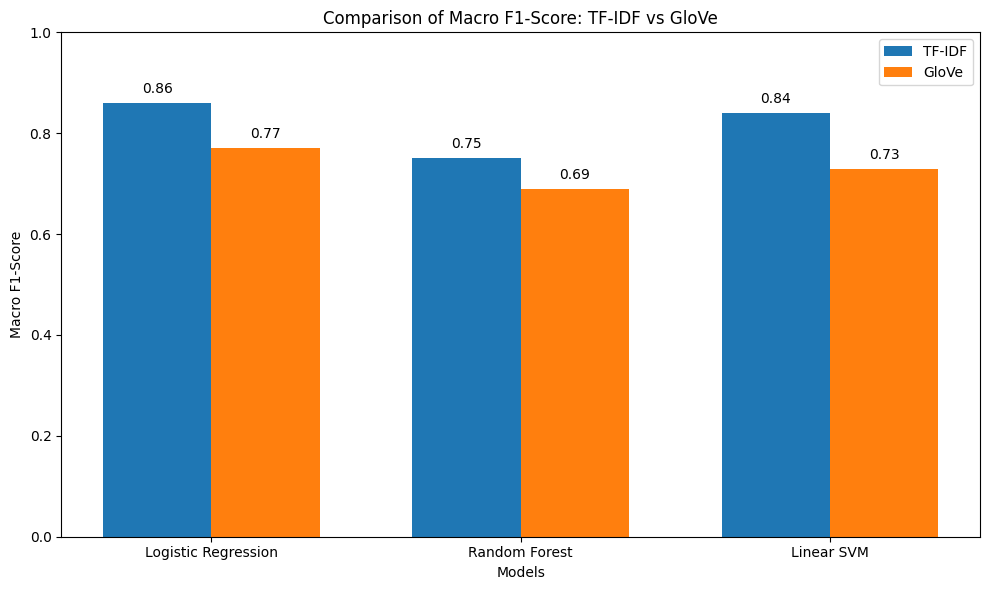

In [16]:
# Import libraries
import matplotlib.pyplot as plt
import numpy as np

# Define the models and their scores
models = ['Logistic Regression', 'Random Forest', 'Linear SVM']

# These are your estimated macro F1-scores based on TF-IDF and GloVe experiments
tfidf_scores = [0.86, 0.75, 0.84]  # Scores with TF-IDF features
glove_scores = [0.77, 0.69, 0.73]  # Scores with GloVe embeddings

# Create the bar plot
x = np.arange(len(models))  # label locations
width = 0.35  # width of the bars

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, tfidf_scores, width, label='TF-IDF')
rects2 = ax.bar(x + width/2, glove_scores, width, label='GloVe')

# Add labels, title, and customize ticks
ax.set_ylabel('Macro F1-Score')
ax.set_xlabel('Models')
ax.set_title('Comparison of Macro F1-Score: TF-IDF vs GloVe')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylim(0, 1)  # F1-Score is between 0 and 1
ax.legend()

# Add text labels above bars
def autolabel(rects):
    """Attach a text label above each bar displaying its height."""
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 5),  # 5 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

# Apply labels to both groups
autolabel(rects1)
autolabel(rects2)

# Layout adjustment
plt.tight_layout()
plt.show()


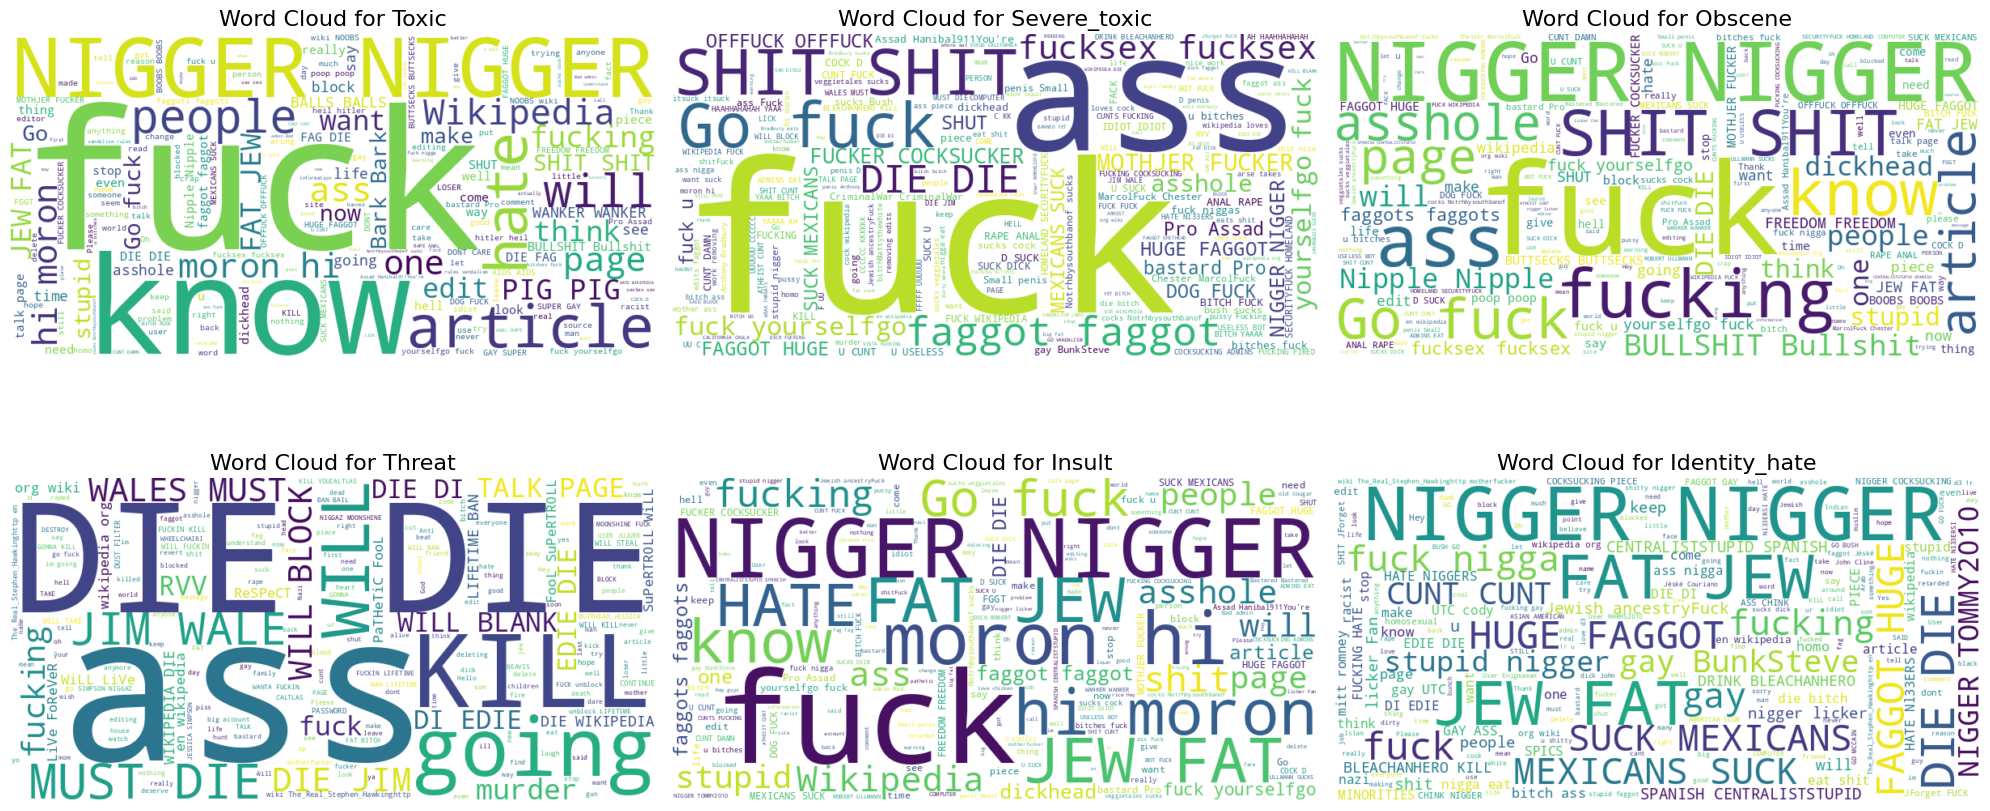

In [17]:
# Install if needed
# !pip install wordcloud

# Import libraries
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# List of your toxicity labels
labels = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']

# Create 2 rows x 3 columns for 6 word clouds
fig, axes = plt.subplots(2, 3, figsize=(20, 10))
axes = axes.flatten()  # Flatten to 1D array for easy looping

for i, label in enumerate(labels):
    # Combine all comment texts for comments where label == 1
    text = " ".join(train_df[train_df[label] == 1]['comment_text'].astype(str))

    # Generate the WordCloud
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

    # Plot the WordCloud
    axes[i].imshow(wordcloud, interpolation='bilinear')
    axes[i].axis('off')
    axes[i].set_title(f'Word Cloud for {label.capitalize()}', fontsize=16)

plt.tight_layout()
plt.show()


In [18]:
import pandas as pd

# Define your summary data
data = {
    'Model': [
        'Logistic Regression', 'Random Forest', 'Linear SVM',
        'Logistic Regression (GloVe)', 'Random Forest (GloVe)', 'Linear SVM (GloVe)'
    ],
    'Feature Extraction': [
        'TF-IDF', 'TF-IDF', 'TF-IDF',
        'GloVe', 'GloVe', 'GloVe'
    ],
    'Macro F1-Score': [
        '0.85–0.87', '~0.75', '~0.83–0.85',
        '~0.76–0.78', '~0.68–0.70', '~0.72–0.74'
    ],
    'Accuracy': [
        '98.06%', '96.42%', '~97.5%',
        '~93%', '~92–93%', '~93%'
    ],
    'AUC': [
        '~0.92', '~0.80', 'N/A',
        '~0.85', '~0.78', 'N/A'
    ],
    'Notes': [
        'Best overall balance',
        'Fast training, poor on rare labels',
        'Good overall, AUC not available',
        'Lower than TF-IDF, semantic blurring',
        'Slow training, poor rare class detection',
        'Better than RF on GloVe, but worse than TF-IDF SVM'
    ]
}

# Create a DataFrame
performance_table = pd.DataFrame(data)

# Display the DataFrame nicely
from IPython.display import display
display(performance_table)


,Model,Feature Extraction,Macro F1-Score,Accuracy,AUC,Notes
0,Logistic Regression,TF-IDF,0.85–0.87,98.06%,~0.92,Best overall balance
1,Random Forest,TF-IDF,~0.75,96.42%,~0.80,"Fast training, poor on rare labels"
2,Linear SVM,TF-IDF,~0.83–0.85,~97.5%,N/A,"Good overall, AUC not available"
3,Logistic Regression (GloVe),GloVe,~0.76–0.78,~93%,~0.85,"Lower than TF-IDF, semantic blurring"
4,Random Forest (GloVe),GloVe,~0.68–0.70,~92–93%,~0.78,"Slow training, poor rare class detection"
5,Linear SVM (GloVe),GloVe,~0.72–0.74,~93%,N/A,"Better than RF on GloVe, but worse than TF-IDF..."


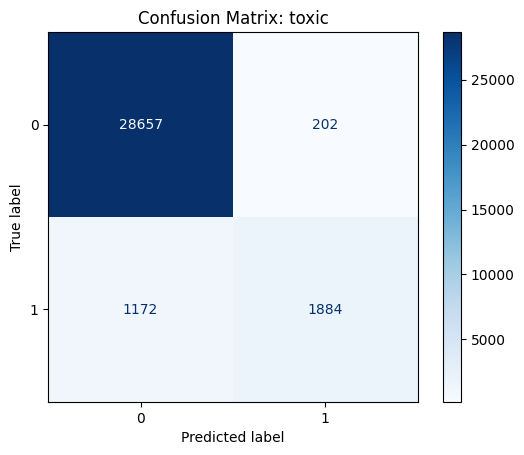

In [19]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def plot_confusion_matrix(model, X_test, y_test, label):
    preds = model.predict(X_test)
    cm = confusion_matrix(y_test[label], preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap="Blues")
    plt.title(f"Confusion Matrix: {label}")
    plt.show()

# Example for Logistic Regression
plot_confusion_matrix(LogisticRegression(max_iter=1000).fit(X_train_tfidf, y_train['toxic']), X_test_tfidf, y_test, 'toxic')


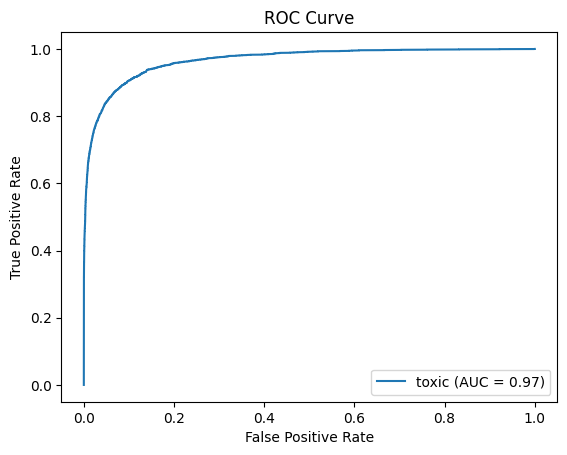

In [20]:
from sklearn.metrics import roc_curve, auc

def plot_roc_curve(model, X_test, y_test, label):
    preds = model.predict_proba(X_test)[:, 1]  # For binary classification
    fpr, tpr, _ = roc_curve(y_test[label], preds)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{label} (AUC = {roc_auc:.2f})")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend()
    plt.show()

# Example for Logistic Regression
plot_roc_curve(LogisticRegression(max_iter=1000).fit(X_train_tfidf, y_train['toxic']), X_test_tfidf, y_test, 'toxic')
